# **CSI 4142: Assignment 4** </br> Unsupervised Learning

## **Group members**
**Group 8**

| Name | Student ID |
|------|------------|
| Zixin Fan | 300296371 |
| Solin Maaroof | 300250903 | 

## **Task distribution**
- Zixin Fan: Clustering (study 2) and Collaborative Filtering (study 4).

- Solin Maaroof: Similarity Measures (study 1) and Content-Based Recommendation System (study 3).

## **Libraries and Packages**

In [80]:
import pandas as pd # For data manipulation and analysis using DataFrames
import numpy as np # For numberical computing and array/ matrix operations
import seaborn as sns # For statistical data visualization with better styling
import matplotlib.pyplot as plt # For creating basic plots and visualizations
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## **Dataset**: The Movies Dataset

### Description
- **Dataset Name:** The Movies Dataset  
- **Owner:** Rounak Banik (Kaggle)
- **Purpose:** This dataset contains metadata and user ratings for movies. It is designed to support tasks such as similarity analysis, clustering, and recommendation systems by providing both item features and user-item interactions.
- **Shape:**
  - movies_metadata.csv: (45466, 24)
  - ratings_small.csv: (100004, 4)
- **Features (movies_metadata.csv):**
  - **Title (Text):** Name of the movie.  
  - **Genres (Categorical):** List of genres associated with the movie (e.g., Action, Comedy).  
  - **Runtime (Numerical):** Duration of the movie in minutes.  
  - **Budget (Numerical):** Production budget of the movie.  
  - **Revenue (Numerical):** Total revenue generated by the movie.  
  - **Popularity (Numerical):** Popularity score based on user engagement.  
- **Features (ratings_small.csv):**
  - **UserId (Categorical):** Unique identifier for each user.  
  - **MovieId (Categorical):** Unique identifier for each movie.  
  - **Rating (Numerical):** Rating given by the user (typically from 0.5 to 5.0).  
  - **Timestamp (Numerical):** Time when the rating was recorded.  

In [81]:
movies_url = "https://drive.google.com/file/d/10ngtfdQl_U7iO-AvbSukkRKCDaT1gDtp/view?usp=drive_link"
movies_url='https://drive.google.com/uc?id=' + movies_url.split('/')[-2]
movies = pd.read_csv(movies_url)
movies.head()

/var/folders/sg/7xkln88170n134s8krr90tcw0000gn/T/ipykernel_22153/2817219307.py:3: DtypeWarning: Columns (0: popularity) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv(movies_url)


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [82]:
movies.shape

(45466, 24)

In [83]:
ratings_url = "https://drive.google.com/file/d/1uM3bE6cuTG8WLy_jkzqaNTBJYjhRuu5v/view?usp=drive_link"
ratings_url='https://drive.google.com/uc?id=' + ratings_url.split('/')[-2]
ratings = pd.read_csv(ratings_url)
ratings.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [84]:
ratings.shape

(100004, 4)

## Data Preparation

### Data type validation

In [85]:
movies.dtypes

adult                        str
belongs_to_collection        str
budget                       str
genres                       str
homepage                     str
id                           str
imdb_id                      str
original_language            str
original_title               str
overview                     str
popularity                object
poster_path                  str
production_companies         str
production_countries         str
release_date                 str
revenue                  float64
runtime                  float64
spoken_languages             str
status                       str
tagline                      str
title                        str
video                     object
vote_average             float64
vote_count               float64
dtype: object

In [86]:
ratings.dtypes

userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object

After separating the validation for the two datasets, I found that the ratings dataset has correct data types and can be directly used. However, the movies dataset has some issues. For example, the budget column is stored as a string instead of a numeric value, which would cause problems for numerical analysis in later studies.

In [87]:
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce')
movies['budget'].dtypes

dtype('float64')

To fix this, I convert budget (and other selected features if needed) into numeric format before performing clustering. This ensures that all features are suitable for numerical computations.

### Check uniqueness errors

In [88]:
movies.duplicated().sum()

np.int64(13)

In [89]:
movies = movies.drop_duplicates()
movies.duplicated().sum()

np.int64(0)

In [90]:
ratings.duplicated().sum()

np.int64(0)

I found that the movies dataset contains 13 duplicate rows, while the ratings dataset has no duplicates. Since duplicate movies may affect clustering results by over-representing certain data points, I remove the duplicates before proceeding. This helps ensure that each movie is only counted once.

### Check presence errors

In [91]:
movies.isna().sum()

adult                        0
belongs_to_collection    40959
budget                       3
genres                       0
homepage                 37673
id                           0
imdb_id                     17
original_language           11
original_title               0
overview                   954
popularity                   5
poster_path                386
production_companies         3
production_countries         3
release_date                87
revenue                      6
runtime                    263
spoken_languages             6
status                      87
tagline                  25045
title                        6
video                        6
vote_average                 6
vote_count                   6
dtype: int64

In [92]:
ratings.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

The ratings dataset does not contain any missing values, so it can be used directly.

In contrast, the movies dataset has many missing values in some columns. However, most of these columns are not relevant for clustering, so they can be ignored.

For the selected numerical features used in subsequent analysis (budget, revenue, and runtime), there are only a few missing values. These missing values are handled during each specific study, depending on the requirements of the analysis.

### Check range errors

In [93]:
(movies[['budget','revenue','runtime']] < 0).sum()

budget     0
revenue    0
runtime    0
dtype: int64

There are no negative values in budget, revenue, or runtime. Therefore, no additional cleaning is required for these features.

### Check consistency errors

In [94]:
ratings['movieId'].isin(movies['id']).sum()

np.int64(0)

All movieId values in the ratings dataset match the movies dataset, so the data is consistent.

### Rating distribution analysis

In [95]:
ratings['rating'].describe()

count    100004.000000
mean          3.543608
std           1.058064
min           0.500000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

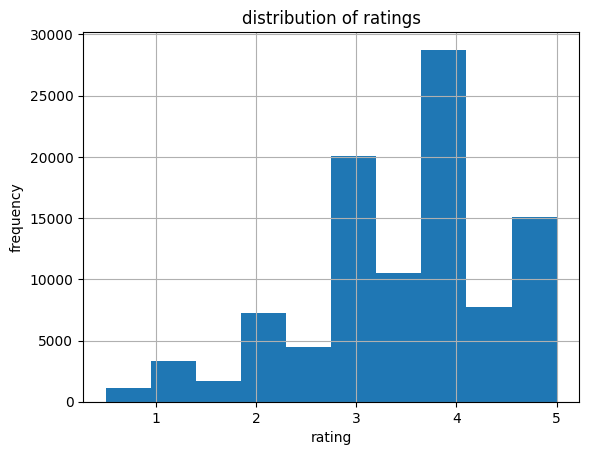

In [96]:
ratings['rating'].hist(bins=10)
plt.title("distribution of ratings")
plt.xlabel("rating")
plt.ylabel("frequency")
plt.show()

The ratings are mostly concentrated between 3 and 5, with a mean of around 3.54. the histogram shows that higher ratings are more frequent than lower ratings. this suggests that users tend to give positive ratings, which is common in recommendation systems since users are more likely to rate items they like.

## Study 2: Clustering algorithms

### Handle missing values (based on data preparation step)

In [97]:
cluster_df=movies[['title', 'budget', 'revenue', 'runtime']].copy()
# drop missing values based on previous data validation results
cluster_df=cluster_df.dropna()
cluster_df[['budget','revenue','runtime']].isna().sum()

budget     0
revenue    0
runtime    0
dtype: int64

### KMeans

#### Revenue versus Budget

In [304]:
scaler=StandardScaler()
combination=cluster_df[['budget','revenue']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale

ks= [2,3,4]
kmeans_results={}
for k in ks:
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    kmeans_results[k]={
        'labels': labels, # store cluster assignments
        'centroids': kmeans.cluster_centers_ # store cluster centers for visualization
    }

##### Visualization for Revenue versus Budget

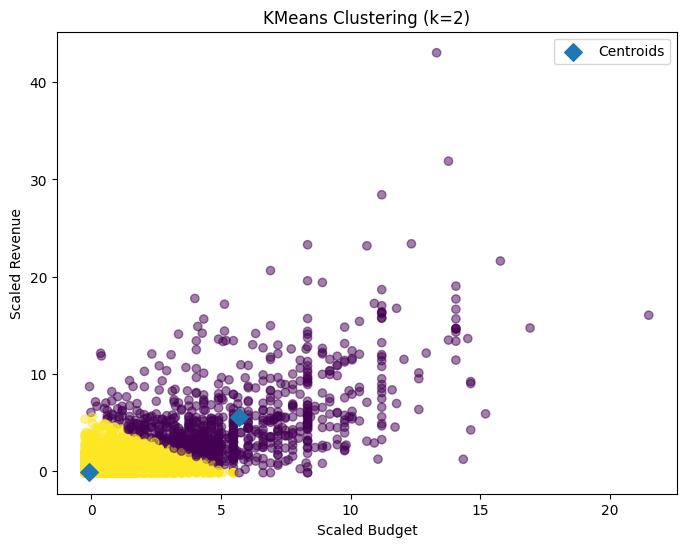

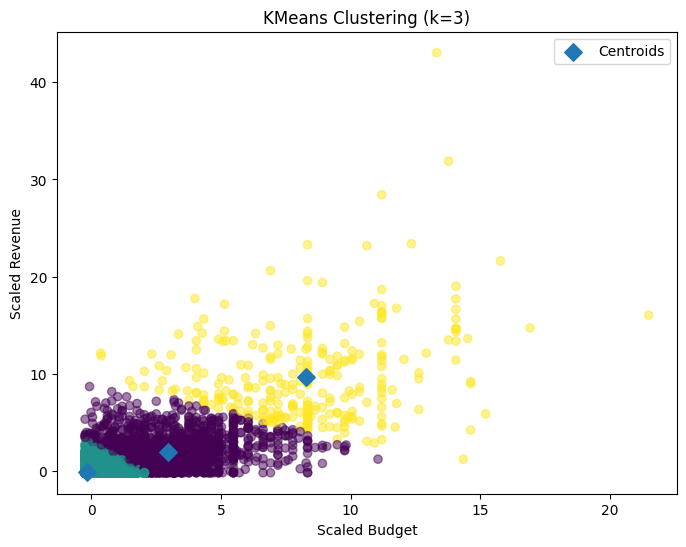

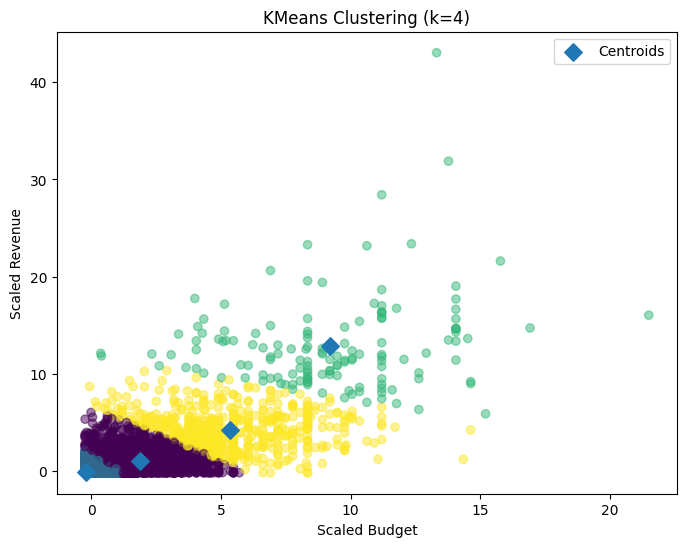

In [305]:
for k in ks:
    plt.figure(figsize=(8, 6))
    labels=kmeans_results[k]['labels']
    centroids=kmeans_results[k]['centroids']
    # plot the clustered data points in the standardized feature space
    plt.scatter(comb_scaled[:, 0], comb_scaled[:, 1], c=labels, alpha=0.5)
    # plot the cluster centroids in the same standardized space
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=80, label='Centroids')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel('Scaled Budget')
    plt.ylabel('Scaled Revenue')
    plt.legend()
    plt.show()

KMeans clustering is applied to group movies based on their budget and revenue. From the visualization, there is a clear positive relationship between budget and revenue, where movies with higher budgets tend to generate higher revenues.

The data points are spread out, allowing KMeans to form more distinct and meaningful clusters. As k increases, the clustering becomes more detailed, separating movies into finer groups based on their financial performance.

However, increasing the number of clusters may also lead to over-segmentation, where similar movies are split into multiple groups. Therefore, selecting an appropriate value of k is important to balance detail and interpretability.

#### Runtime versus Budget

In [306]:
scaler=StandardScaler()
combination=cluster_df[['runtime','budget']] # select the two features used for clustering
comb_scaled=scaler.fit_transform(combination) # standardize the features so they are on the same scale

ks= [2,3,4]
kmeans_results={}
for k in ks:
    kmeans=KMeans(n_clusters=k, random_state=42)
    labels=kmeans.fit_predict(comb_scaled) # fit the model and assign a cluster label to each point
    kmeans_results[k]={
        'labels': labels, # store cluster assignments
        'centroids': kmeans.cluster_centers_ # store cluster centers for visualization
    }

##### Visualization for Runtime versus Budget

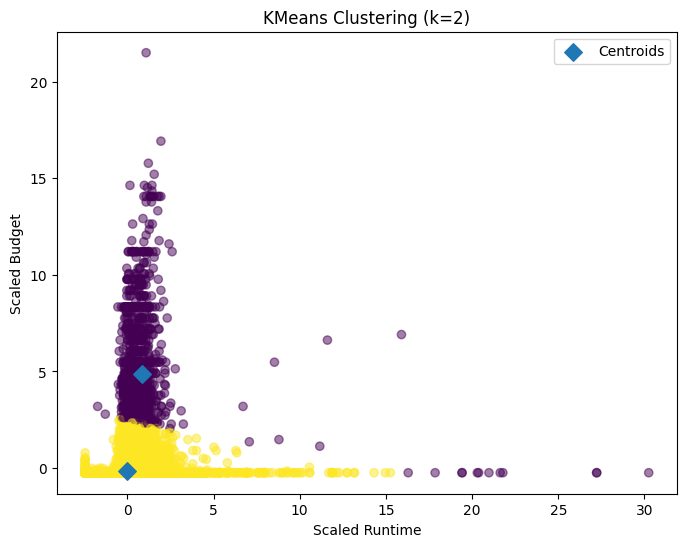

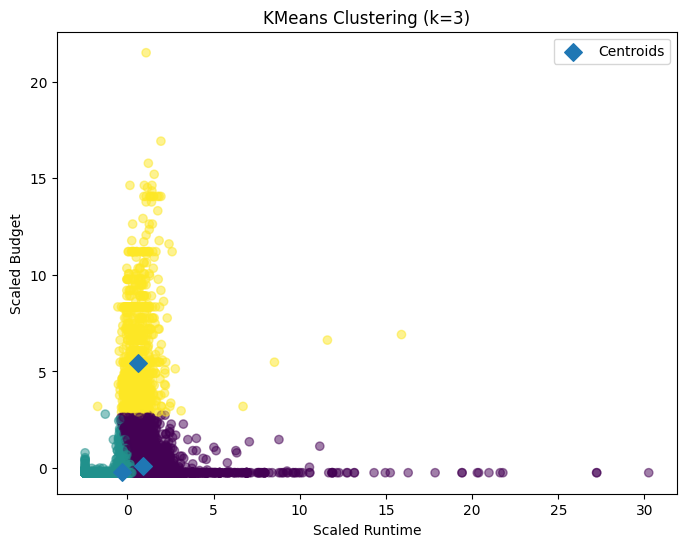

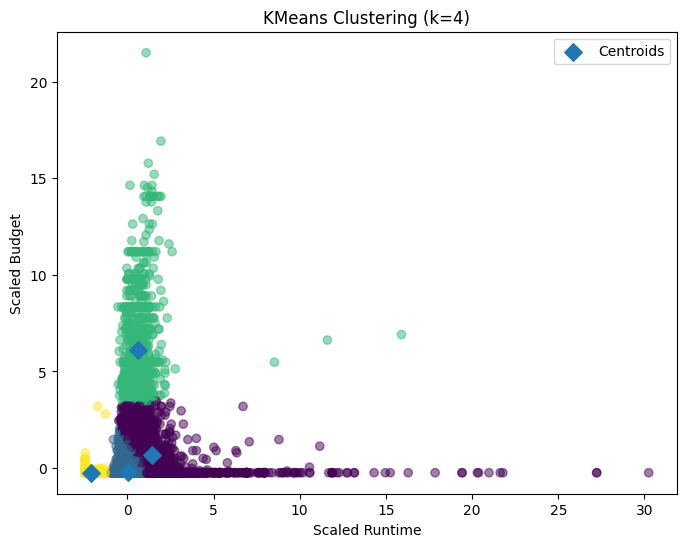

In [307]:
for k in ks:
    plt.figure(figsize=(8, 6))
    labels=kmeans_results[k]['labels']
    centroids=kmeans_results[k]['centroids']
    # plot the clustered data points in the standardized feature space
    plt.scatter(comb_scaled[:, 0], comb_scaled[:, 1], c=labels, alpha=0.5)
    # plot the cluster centroids in the same standardized space
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='D', s=80, label='Centroids')
    plt.title(f'KMeans Clustering (k={k})')
    plt.xlabel('Scaled Runtime')
    plt.ylabel('Scaled Budget')
    plt.legend()
    plt.show()

KMeans clustering is applied to group movies based on their runtime and budget. From the visualization, most movies are concentrated within a narrow range of runtime values, forming a vertical pattern, while budget values vary more widely.

There is no strong linear relationship between runtime and budget, as movies with similar runtime can have significantly different budgets. As a result, the clustering is mainly driven by differences in budget rather than runtime.

As k increases, the clusters become more detailed. However, similar to the previous analysis, larger values of k may lead to over-segmentation, reducing the interpretability of the clusters.

#### Comparison

Comparing the two analyses, revenue shows a stronger relationship with budget than runtime. In the revenue vs budget plot, the clusters are more clearly separated, indicating that revenue is an important factor in distinguishing groups of movies.

In contrast, runtime does not provide strong separation, as most movies have similar runtimes. Therefore, budget and revenue together produce more meaningful clustering results than budget and runtime.

This suggests that revenue is a more informative feature for clustering movies, while runtime contributes less to distinguishing different groups.

### DBSCAN

#### Revenue versus Budget

#### Runtime versus Budget

## Study 4: Collaborative Filtering Recommendation System

### Utility Matrix Construction

In [308]:
R = ratings.pivot(index='userId',columns='movieId',values='rating') # use.pivot to construct the matrix
R.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [309]:
print("Number of users:",R.shape[0])
print("Number of movies:",R.shape[1])

Number of users: 671
Number of movies: 9066


In [310]:
R.isna().sum().sum() # these missing values indicate user-item pairs where no rating was provided, meaning the user has not interacted with the item.

np.int64(5983282)

we construct the utility matrix, where each row represents a user and each column represents a movie. the values correspond to the ratings given by users. since users only rate a small subset of movies (resulting in 5,983,282 missing values), the matrix is highly sparse, which is typical in collaborative filtering systems.

### Train-Test Split (90%+10%)

In [311]:
def split_gold_standard(ratings_df,test_ratio=0.1,random_state=42): # 90 train + 10 test
    np.random.seed(random_state) # set random seed
    train_set=[] # train data for each user
    test_set=[] # test data for each user
    
    for _, each_user_info in ratings_df.groupby('userId'): # group the dataset by userId (each user is processed separately)
        test_size=max(1, int(len(each_user_info) * test_ratio)) # number of test samples for this user (at least 1)
        test_idx=np.random.choice(each_user_info.index, size=test_size, replace=False) # randomly select indices for test set without replacement
        test=each_user_info.loc[test_idx] # extract the selected test samples
        train=each_user_info.drop(test_idx) # remaining samples are used as training data
        train_set.append(train)
        test_set.append(test)
    
    train_df=pd.concat(train_set).reset_index(drop=True) # combine all users' train data into one dataframe and reset index
    test_df=pd.concat(test_set).reset_index(drop=True)   # combine all users' test data into one dataframe and reset index
    return train_df, test_df

In [312]:
train_ratings, test_ratings=split_gold_standard(ratings)
print("Train size:",train_ratings.shape)
print("Test size:",test_ratings.shape)

Train size: (90282, 4)
Test size: (9722, 4)


To evaluate our model, we split the dataset into training (90%) and test (10%) sets. The split is performed per user to ensure that each user appears in both sets. This is important in collaborative filtering to avoid cold-start issues during evaluation. The test set will serve as the Gold Standard (GS) for evaluation.

### Reconstruction of Utility Matrix using Only the Training Dataset

In [313]:
train_matrix=train_ratings.pivot(index='userId',columns='movieId',values='rating')
train_matrix.shape
train_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [314]:
train_matrix_0=train_matrix.fillna(0) # assume that unrated items correspond to no interaction (0)
train_matrix_0.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,160718,161084,161155,161594,161830,161918,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We reconstruct the utility matrix using only the training dataset. This ensures that the model does not have access to test data during training, preventing data leakage.

### Model-Based Collaborative Filtering (Matrix Factorization)

In [315]:
def matrix_factorization_svd(train_matrix, dim=20, random_state=42):
    svd=TruncatedSVD(n_components=dim, random_state=random_state) # use truncated SVD to reduce the dimension of the matrix
    user_features=svd.fit_transform(train_matrix) # transform the original matrix into lower-dimensional user features
    item_features=svd.components_ # get item features (each row corresponds to a latent factor for items)
    pred_ratings=np.dot(user_features, item_features) # reconstruct the rating matrix by multiplying user and item factors
    
    pred_df = pd.DataFrame(
        pred_ratings,
        index=train_matrix.index, # keep same user id
        columns=train_matrix.columns # keep same movie id
    )
    
    return pred_df

We use Singular Value Decomposition (SVD) to perform matrix factorization on the utility matrix. We break the original user–item matrix into two smaller matrices: one representing user preferences and the other representing item characteristics in a lower-dimensional space. By multiplying these two matrices, we can reconstruct the original matrix and obtain predicted ratings for missing entries. This helps us estimate how a user might rate movies they have not seen yet.

### Evaluation 1: MSE for Different Latent Dimensions

In [316]:
def evaluate_mse(test_df, pred_df):
    true_ratings=[]
    pred_ratings=[]
    
    for _, row in test_df.iterrows():
        user=row['userId']
        movie=row['movieId']
        true_rating=row['rating'] # extract true values from original matrix
        
        if user in pred_df.index and movie in pred_df.columns: # ensure the user-item pair exists in the predicted matrix
            pred_rating=pred_df.loc[user, movie] # extract predicted values from the train predicted matrix
            true_ratings.append(true_rating)
            pred_ratings.append(pred_rating)
    
    mse=mean_squared_error(true_ratings,pred_ratings)
    return mse

In [317]:
latent_dims=[5,30,60] # test different dimensions (different complexity)
predictions={} # store different models (different complexity)
mse_results={} # store mse results corresponding to each model with different dimensions
for k in latent_dims:
    # train the model
    pred_ratings=matrix_factorization_svd(train_matrix_0,dim=k)
    predictions[k]=pred_ratings
    # evaluate the model
    mse=evaluate_mse(test_ratings,pred_ratings)
    mse_results[k]=mse
    print(f"k={k}, MSE={mse}")

k=5, MSE=8.616344388394817
k=30, MSE=8.974431139301995
k=60, MSE=9.988088462081326


We observe that as the latent dimension k increases, the MSE also increases. This suggests that larger latent dimensions may lead to overfitting, especially given the high sparsity of the dataset.

### Evaluation 2: P@K (5&10) and MRR

#### Randomly select three users

In [318]:
sample_users = np.random.choice(test_ratings['userId'].unique(), size=3, replace=False) # randomly select 3 users from the test set (for evaluation)
sample_users

array([195, 116, 414])

#### Top-k recommendation

In [319]:
def get_top_k_recommendations(user_id, pred_df, train_df, k=5):
    user_predictions=pred_df.loc[user_id] # get predicted ratings for this user (a row from predicted matrix)
    watched_movies=train_df[train_df['userId']==user_id]['movieId'].values # find movies that this user has already watched in the training set
    recommendations=user_predictions.drop(watched_movies, errors='ignore') # remove already watched movies from recommendations
    top_k = recommendations.sort_values(ascending=False).head(k) # sort remaining movies by predicted rating (descending) and take top k
    return top_k

In [320]:
for user in sample_users:
    print("User ID:",user)
    top_k=get_top_k_recommendations(user, predictions[5], train_ratings, k=5)
    print(top_k)
    print("\n")

User ID: 195
movieId
750     3.038716
1617    3.004884
904     2.744881
1208    2.725108
1079    2.626939
Name: 195, dtype: float64


User ID: 116
movieId
110    1.196340
527    1.177643
589    1.114268
50     1.042045
150    0.980414
Name: 116, dtype: float64


User ID: 414
movieId
296    0.312757
608    0.312557
318    0.287509
527    0.281163
593    0.273269
Name: 414, dtype: float64




For each selected user, we generate top-k recommendations based on predicted ratings from the model. We first remove movies that the user has already watched in the training set, then sort the remaining movies by predicted ratings in descending order. The top k movies are selected as recommendations.

#### Binary relevence

In [321]:
def get_relevant_items(test_df):
    relevant=test_df[test_df['rating']>=4] # select items with rating>=4 as relevant (binary relevance)
    return relevant

#### P@K

In [322]:
def precision_at_k(user_id, pred_df, train_df, test_df, k):
    top_k=get_top_k_recommendations(user_id, pred_df, train_df, k) # get top-k recommendations for this user
    relevant=get_relevant_items(test_df[test_df['userId']==user_id]) # get relevant items (ground truth) from test set
    relevant_movies=set(relevant['movieId']) # convert to set for fast lookup
    hits=sum([1 for movie in top_k.index if movie in relevant_movies]) # count how many recommended items are actually relevant (hits)
    return hits/k # precision

We use binary relevance to evaluate recommendations. Items with rating>=4 are considered relevant, and others are treated as non-relevant. For each user, we compare the top-k recommended movies with the relevant movies in the test set. If a recommended movie appears in the relevant set, it is counted as a hit.

##### P@5

In [323]:
for user in sample_users:
    print("User ID:",user)
    top_k = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_k)
    # evaluation
    p5 = precision_at_k(user, predictions[5], train_ratings, test_ratings, k=5)
    print("P@5:",p5)
    print("\n")
    

User ID: 195
movieId
750     3.038716
1617    3.004884
904     2.744881
1208    2.725108
1079    2.626939
1288    2.580412
924     2.569734
1089    2.505832
1265    2.485952
2762    2.381438
Name: 195, dtype: float64
P@5: 0.2


User ID: 116
movieId
110     1.196340
527     1.177643
589     1.114268
50      1.042045
150     0.980414
1196    0.963530
457     0.938491
608     0.865541
590     0.864810
1198    0.849272
Name: 116, dtype: float64
P@5: 0.0


User ID: 414
movieId
296     0.312757
608     0.312557
318     0.287509
527     0.281163
593     0.273269
912     0.258679
2858    0.251095
858     0.242836
1193    0.233402
457     0.233387
Name: 414, dtype: float64
P@5: 0.0




The precision@5 values are relatively low, which indicates that only a small proportion of the recommended items are actually relevant to the users. This suggests that the model has limited ability to rank highly relevant items at the top positions.

##### P@10

In [324]:
for user in sample_users:
    print("User ID:",user)
    top_k = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_k)
    # evaluation
    p10 = precision_at_k(user, predictions[5], train_ratings, test_ratings, k=10)
    print("P@10:",p10)
    print("\n")

User ID: 195
movieId
750     3.038716
1617    3.004884
904     2.744881
1208    2.725108
1079    2.626939
1288    2.580412
924     2.569734
1089    2.505832
1265    2.485952
2762    2.381438
Name: 195, dtype: float64
P@10: 0.2


User ID: 116
movieId
110     1.196340
527     1.177643
589     1.114268
50      1.042045
150     0.980414
1196    0.963530
457     0.938491
608     0.865541
590     0.864810
1198    0.849272
Name: 116, dtype: float64
P@10: 0.0


User ID: 414
movieId
296     0.312757
608     0.312557
318     0.287509
527     0.281163
593     0.273269
912     0.258679
2858    0.251095
858     0.242836
1193    0.233402
457     0.233387
Name: 414, dtype: float64
P@10: 0.0




The precision@10 values tend to be lower or similar compared to precision@5. this is expected, as increasing the number of recommended items usually introduces more irrelevant items. This shows that the model’s recommendation quality decreases as the list becomes longer. We randomly select a few users for evaluation, so the exact precision values may vary across runs, but the overall trend remains consistent.

#### MRR

In [325]:
def reciprocal_rank(user_id, R_pred_df, train_df, test_df):
    top_10 = get_top_k_recommendations(user_id, R_pred_df, train_df, k=10) # get top-10 recommended items for this user
    relevant = get_relevant_items(test_df[test_df['userId'] == user_id]) # get relevant items (rating >= 4) for this user from test set
    relevant_movies = set(relevant['movieId']) # convert relevant movie list to a set for faster lookup
    for rank, movie in enumerate(top_10.index, start=1):
        if movie in relevant_movies: # check if the recommended movie is actually relevant
            return 1/rank # reciprocal rank
    return 0 # if no relevant item appears in top-k recommendations

In [326]:
for user in sample_users:
    print("User ID:",user)
    top_10 = get_top_k_recommendations(user, predictions[5], train_ratings, k=10)
    print(top_10)
    # evaluation
    mrr = reciprocal_rank(user, predictions[5], train_ratings, test_ratings)
    print("MRR:",mrr)
    print("\n")

User ID: 195
movieId
750     3.038716
1617    3.004884
904     2.744881
1208    2.725108
1079    2.626939
1288    2.580412
924     2.569734
1089    2.505832
1265    2.485952
2762    2.381438
Name: 195, dtype: float64
MRR: 0.25


User ID: 116
movieId
110     1.196340
527     1.177643
589     1.114268
50      1.042045
150     0.980414
1196    0.963530
457     0.938491
608     0.865541
590     0.864810
1198    0.849272
Name: 116, dtype: float64
MRR: 0


User ID: 414
movieId
296     0.312757
608     0.312557
318     0.287509
527     0.281163
593     0.273269
912     0.258679
2858    0.251095
858     0.242836
1193    0.233402
457     0.233387
Name: 414, dtype: float64
MRR: 0




MRR measures how early the first relevant item appears in the recommendation list. If a relevant item shows up at position k, the score is 1/k, and if no relevant item appears in the top-10, the score is 0. In our implementation, we go through the top-10 recommendations and return the reciprocal rank of the first relevant item we find.

From the results, we can see that the MRR values are generally low, meaning relevant items are often not ranked at the very top. This is expected given the nature of the problem. The dataset is quite sparse, so the model does not have much information about each user’s preferences. Also, the SVD model is mainly optimized for predicting ratings (minimizing MSE), rather than directly improving ranking quality. Because of this, even if the predicted ratings are reasonable, the ranking itself may not be very accurate. In addition, since we only evaluate a few randomly selected users, the exact MRR values may vary each time we run the code. Overall, these results suggest that the model has limited ability to place highly relevant items at the top of the recommendation list.

## **References**

Some code snippets and explanations were generated with the assistance of generative AI.
Queries include:
- how to use KMeans for clustering in sklearn
- how to use StandardScaler and fit_transform for feature scaling
- how to use fit_predict to obtain cluster labels
- how to visualize KMeans clustering results using matplotlib
- how to plot cluster centroids in a scatter plot
- understand how to use `.pivot()` in pandas to construct a user-item utility matrix
- how to perform user-based train-test split using pandas groupby
- how to randomly sample indices using numpy (np.random.choice)
- how to concatenate multiple dataframes using pd.concat and reset index
- understand how to apply matrix factorization using `TruncatedSVD` from `sklearn.decomposition`
- understand how to reconstruct the rating matrix using `np.dot` after SVD
- understand how to convert the reconstructed matrix into a pandas DataFrame for evaluation
- how to format and print multiple variables together using f-strings (e.g., print(f"k={k}, MSE={mse}"))
- how to implement top-k recommendation by filtering watched items and ranking predicted scores
- understand why recommendation performance (P@K and MRR) may be low in SVD-based collaborative filtering models, especially in sparse datasets and when optimizing for MSE rather than ranking

Datasets: https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset

Online resources:
- https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d (used as a reference for visualizing KMeans clustering results and plotting cluster centroids)
- https://stackoverflow.com/questions/56611698/pandas-how-to-read-csv-file-from-google-drive-public (used to understand how to load CSV files from Google Drive into pandas)

Official documentation:
- https://pandas.pydata.org/docs/  
- https://numpy.org/doc/  
- https://matplotlib.org/stable/tutorials/index
- https://seaborn.pydata.org/tutorial.html